<a href="https://colab.research.google.com/github/yashaswikarthikreddydanda/yashaswikarthikreddydanda.github.io/blob/main/Multiframe_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2

print(os.listdir('/content'))

['.config', 'im3.png', 'im7.png', 'im6.png', 'im2.png', 'im5.png', 'im1.png', 'im4.png', 'sample_data']


In [2]:
import cv2
images =[]

for i in range(1,8):
  path = f"/content/im{i}.png"
  img = cv2.imread(path,cv2.IMREAD_GRAYSCALE)

  images.append(img)

print('Length of the image folder:',len(images))




Length of the image folder: 7


In [3]:
from google.colab.patches import cv2_imshow
ref_image = images[3];


In [4]:
pastimg=[];
for i in range(0,3):
 img = images[i];
 pastimg.append(img)

len(pastimg)

3

separated our frames as past images to apply backward optical flow for t-3 frames.

In [5]:
futureimg= [];
for i in range(4,7):
 img = images[i];
 futureimg.append(img)

len(futureimg)

3

separated our frames as future images to apply forward optical flow for t+3 frames.

In [62]:
flow_p =[]
for i in range(0,3):
  flow = cv2.calcOpticalFlowFarneback(
    pastimg[i], ref_image,
    None,
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)
  flow_p.append(flow)
len(flow_p)

3

Motion vectors generated by the forward optical flow algorithm for all 3 past frames are stored in the flow_p vector.

In [63]:
flow_f =[]
for i in range(0,3):
  flow = cv2.calcOpticalFlowFarneback(
    ref_image,futureimg[i],
    None,
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0

)
  flow_f.append(flow)
len(flow_f)

3

In [64]:
import numpy as np
[H,W] = ref_image.shape
print(H,W)
flow_f = np.array(flow_f)
flow_p = np.array(flow_p)

256 448


In [65]:
def warp_frame(src,flow_p):
  x = np.arange(0,W)
  y = np.arange(0,H)
  x,y = np.meshgrid(x,y)
  return cv2.remap(src,x+flow_p[:,:,0],y+flow_p[:,:,1],cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)



In [66]:
def warp_frame(src,flow_f):
  x = np.arange(0,W)
  y = np.arange(0,H)
  x,y = np.meshgrid(x,y)
  return cv2.remap(src,x-flow_f[:,:,0],y-flow_f[:,:,1],cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

In [67]:
import numpy as np
import cv2

# Redefine the warp_frame function with the fix to ensure map types are float32
def warp_frame(src, flow_p):
  # Create coordinate grids, ensuring float32 type
  x = np.arange(0, W, dtype=np.float32)
  y = np.arange(0, H, dtype=np.float32)
  x_grid, y_grid = np.meshgrid(x, y)

  # Calculate the warped coordinates and explicitly cast to float32
  map_x = (x_grid + flow_p[:,:,0]).astype(np.float32)
  map_y = (y_grid + flow_p[:,:,1]).astype(np.float32)

  return cv2.remap(src, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

warped_frames = []
for i in range(3):
    warped = warp_frame(futureimg[i], flow_p[i])
    warped_frames.append(warped)

In [68]:
def warp_frame(src, flow_f):
  # Create coordinate grids, ensuring float32 type
  x = np.arange(0, W, dtype=np.float32)
  y = np.arange(0, H, dtype=np.float32)
  x_grid, y_grid = np.meshgrid(x, y)

  # Calculate the warped coordinates and explicitly cast to float32
  map_x = (x_grid - flow_f[:,:,0]).astype(np.float32)
  map_y = (y_grid - flow_f[:,:,1]).astype(np.float32)

  return cv2.remap(src, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

warped_frames_f = []
for i in range(3):
    warped = warp_frame(pastimg[i], flow_f[i])
    warped_frames_f.append(warped)

In [98]:
all_warped = warped_frames + warped_frames_f
residuals = [w.astype(np.float32) - ref_image.astype(np.float32) for w in all_warped]

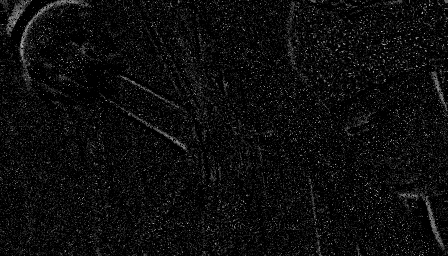

In [112]:
len(residuals)
cv2_imshow(residuals[2])
residual_magnitudes = [np.mean(np.abs(r)) for r in residuals]

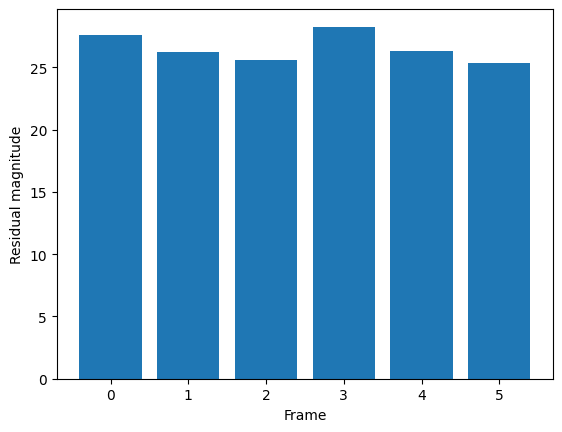

In [111]:
import matplotlib.pyplot as plt
plt.bar(range(len(residual_magnitudes)), residual_magnitudes)
plt.xlabel('Frame')
plt.ylabel('Residual magnitude')
plt.show()

In [138]:
def block_ssim_aggregate(ref, all_warped, block_size=10):
    H, W = ref.shape
    pad_h = (block_size - H % block_size) % block_size
    pad_w = (block_size - W % block_size) % block_size

    ref_pad = np.pad(ref, ((0, pad_h), (0, pad_w)), mode='reflect')
    warped_pad = [np.pad(w, ((0, pad_h), (0, pad_w)), mode='reflect') for w in all_warped]

    H_pad, W_pad = ref_pad.shape
    output = np.zeros((H_pad, W_pad), dtype=np.float32)

    for by in range(0, H_pad, block_size):
        for bx in range(0, W_pad, block_size):
            ref_block = ref_pad[by:by+block_size, bx:bx+block_size]
            block_scores, block_patches = [], []
            for w in warped_pad:
                patch = w[by:by+block_size, bx:bx+block_size]
                score = ssim(ref_block, patch, data_range=255)
                block_scores.append(score)
                block_patches.append(patch)

            patches = block_patches + [ref_block]
            scores = block_scores + [1.0]
            weights = np.array(scores)
            weights = weights / weights.sum()
            output[by:by+block_size, bx:bx+block_size] = np.average(patches, axis=0, weights=weights)

    return np.clip(output[:H, :W], 0, 255).astype(np.uint8)

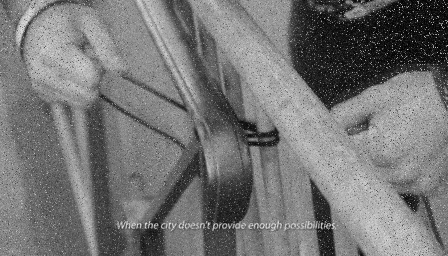

In [146]:
result = block_ssim_aggregate(ref_image, all_warped, block_size=64)
cv2_imshow(result)

In [139]:
cv2_imshow(result)

NameError: name 'result' is not defined

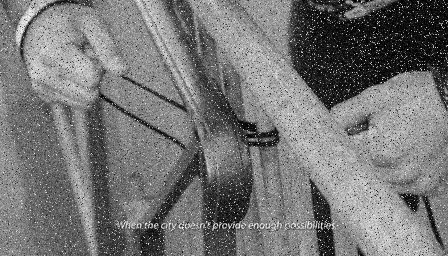

In [142]:

cv2_imshow(ref_image)

In [76]:
print(warped_frames_f[1].shape)

(256, 448)


In [75]:
print(warped_frames[1].shape)

(256, 448)


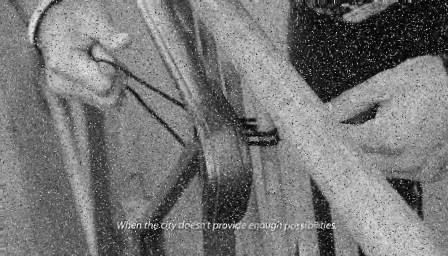

In [51]:
from google.colab.patches import cv2_imshow
cv2_imshow(warped_frames_f[0])

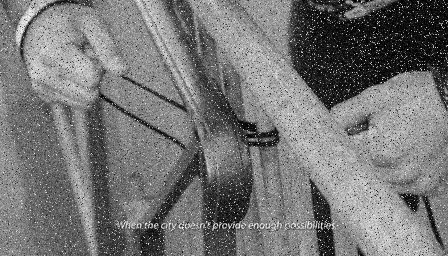

In [89]:
cv2_imshow(ref_image)

In [96]:
def gaussian_weights(n, sigma=1.0):
    x = np.arange(n)
    w = np.exp(-x**2 / (2 * sigma**2))
    return w / w.sum()

weights = gaussian_weights(len(warped_frames), sigma=1.0)
aggregated = np.average(warped_frames, axis=0, weights=weights).astype(np.uint8)

In [92]:
all_frames = warped_frames + warped_frames_f
aggregated = np.mean(all_frames, axis=0).astype(np.uint8)

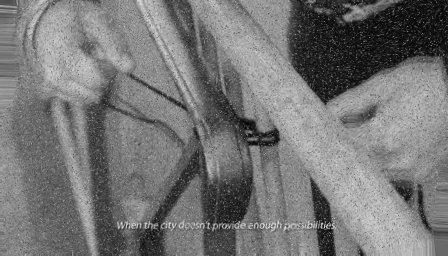

In [97]:
cv2_imshow(aggregated)

In [74]:
h,w = warped_frames_f.shape
print(h,w)


AttributeError: 'list' object has no attribute 'shape'

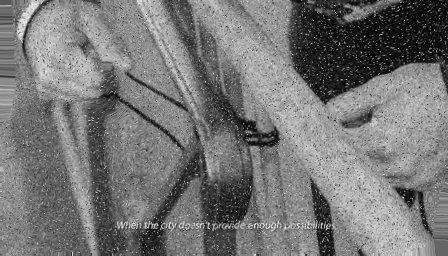

In [ ]:
from google.colab.patches import cv2_imshow
cv2_imshow(warped_frames[1])
